Цель: Изучить применение методов по поиску выбросов в данных, попрактиковаться в обработке экстремальных значений.

Описание задания:
В домашнем задании нужно решить задачу классификации типа стекол.

- Проведите первичный анализ. Проверьте количество записей для каждого класса. Сделайте вывод.
- Разделите выборку на обучающее и тестовое подмножество. 80% данных оставить на обучающее множество, 20% на тестовое.
- Обучите модель дерева решений RandomForestClassifier https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html на обучающем множестве.
- Для тестового множества предскажите тип стекла и сравните с истинным значением, посчитав точность предсказания модели (accuracy).
- Обработайте выбросы в данных.

а) Визуализируйте распределение значений для каждой переменной. Можно использовать функции sns.boxplot https://seaborn.pydata.org/generated/seaborn.boxplot.html,
 sns.distplot https://seaborn.pydata.org/generated/seaborn.displot.html#seaborn.displot.
Есть ли признаки с нормальным распределением?

b) Исследуйте признаки на выбросы несколькими способами.

c) Удалите выбросы.

*Посчитайте процент удаленных записей от общего числа записей для каждого класса.
- Повторите п. 4, п. 5.
- Сформулируйте выводы по проделанной работе.
а) Кратко опишите, какие преобразования были сделаны с данными.
b) Сравните точность двух моделей.
c) Напишите свое мнение, нужно ли исследовать данные на выбросы, для чего это делается, плюсы и минусы подхода.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import accuracy_score
from matplotlib import pyplot as plt
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from sklearn.cluster import DBSCAN
from sklearn.pipeline import make_pipeline

### 2 вариант

In [ ]:
data = pd.read_csv('glass.csv')
data.head(3)

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1


In [ ]:
data.Type.value_counts()
# несбалансированные классы

,count
Type,
2,76
1,70
7,29
3,17
5,13
6,9


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


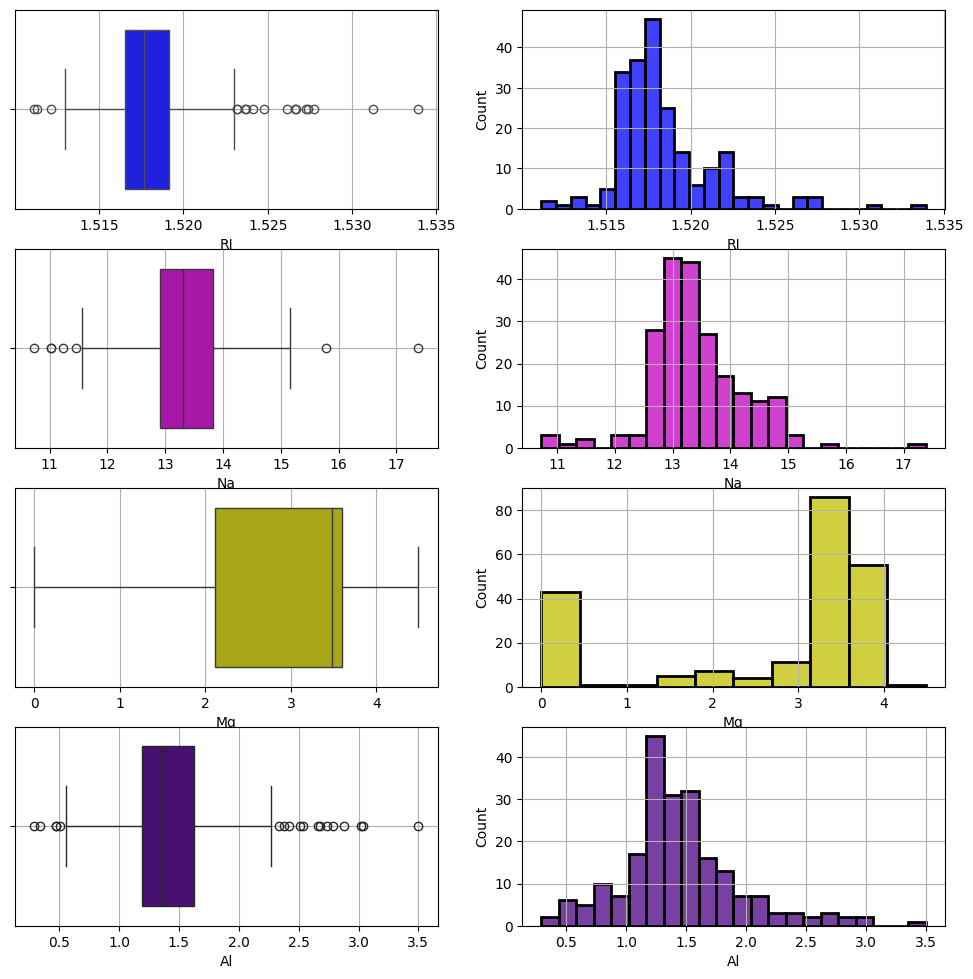

In [ ]:
plt.figure(figsize=(12,15))
plt.subplot(521)
sns.boxplot(x=data['RI'], color='b')
plt.grid()
plt.subplot(522)
sns.histplot(x=data['RI'], color='b', linewidth=2)
plt.grid()

plt.subplot(523)
sns.boxplot(x=data['Na'], color='m')
plt.grid()
plt.subplot(524)
sns.histplot(x=data['Na'], color='m', linewidth=2)
plt.grid()

plt.subplot(525)
sns.boxplot(x=data['Mg'], color='y')
plt.grid()
plt.subplot(526)
sns.histplot(x=data['Mg'], color='y', linewidth=2)
plt.grid()

plt.subplot(527)
sns.boxplot(x=data['Al'], color='indigo')
plt.grid()
plt.subplot(528)
sns.histplot(x=data['Al'], color='indigo', linewidth=2)
plt.grid()

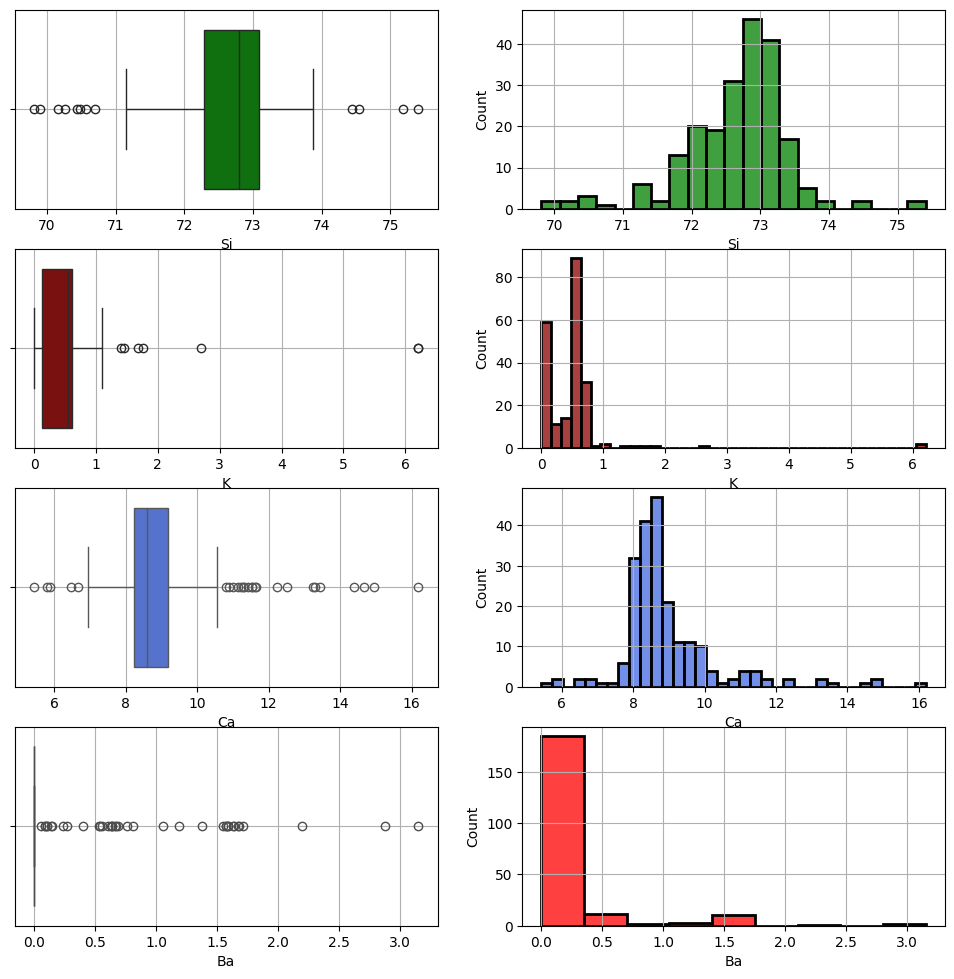

In [ ]:
plt.figure(figsize=(12,15))
plt.subplot(521)
sns.boxplot(x=data['Si'], color='g')
plt.grid()
plt.subplot(522)
sns.histplot(x=data['Si'], color='g', linewidth=2)
plt.grid()

plt.subplot(523)
sns.boxplot(x=data['K'], color='darkred')
plt.grid()
plt.subplot(524)
sns.histplot(x=data['K'], color='darkred', linewidth=2)
plt.grid()

plt.subplot(525)
sns.boxplot(x=data['Ca'], color='royalblue')
plt.grid()
plt.subplot(526)
sns.histplot(x=data['Ca'], color='royalblue', linewidth=2)
plt.grid()

plt.subplot(527)
sns.boxplot(x=data['Ba'], color='r')
plt.grid()
plt.subplot(528)
sns.histplot(x=data['Ba'], color='r', linewidth=2)
plt.grid()

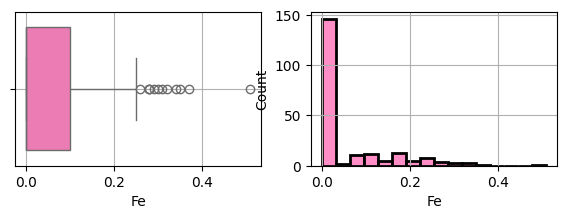

In [ ]:
plt.figure(figsize=(7,2))
plt.subplot(121)
sns.boxplot(x=data['Fe'], color='hotpink')
plt.grid()
plt.subplot(122)
sns.histplot(x=data['Fe'], color='hotpink', linewidth=2)
plt.grid()

In [ ]:
data.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


In [ ]:
np.random.seed(9)
train = data[:150]
test = data[150:]

In [ ]:
ocsvm1 = OneClassSVM(kernel="rbf", nu=0.1)
ocsvm1.fit(train)
print(ocsvm1.predict(test))

[ 1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1]


In [ ]:
clf1 = IsolationForest(random_state=0)
clf1.fit(train)
print(clf1.predict(test))

[ 1 -1  1  1  1  1  1  1  1  1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1  1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1]


In [ ]:
lof = LocalOutlierFactor(novelty=True)
lof.fit(data)
print(lof.predict(data))

[ 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1 -1 -1 -1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1
  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1
  1 -1  1  1  1 -1 -1 -1  1  1 -1 -1  1 -1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1 -1 -1 -1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1 -1  1 -1  1  1  1  1  1  1  1  1  1  1 -1 -1  1  1  1  1
  1  1  1 -1 -1  1  1  1  1  1  1  1 -1  1  1  1 -1 -1 -1  1 -1 -1  1  1
  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1 -1  1  1  1  1  1  1]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


In [ ]:
db = DBSCAN(eps=0.7, min_samples=20).fit(data)
db.labels_

array([-1, -1,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,
       -1, -1,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0, -1,  0, -1, -1,  0,  0,  0, -1,  0, -1,  0, -1, -1, -1, -1,
        0,  0,  0,  0, -1,  0,  0,  0,  0,  0, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1, -1, -1, -1, -1, -1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1])

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(data.drop(columns='Type'), data['Type'], test_size=0.2, random_state=9)

In [ ]:
pipe = make_pipeline(MinMaxScaler(), RandomForestClassifier(class_weight='balanced', random_state=0))
pipe.fit(x_train, y_train)

Pipeline(steps=[('minmaxscaler', MinMaxScaler()),
                ('randomforestclassifier',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=0))])

In [ ]:
pred = pipe.predict(x_test)
res = accuracy_score(y_test, pred)
res

0.627906976744186

In [ ]:
pipe2 = make_pipeline(StandardScaler(), RandomForestClassifier(class_weight='balanced', random_state=0))
pipe2.fit(x_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('randomforestclassifier',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=0))])

In [ ]:
pred2 = pipe2.predict(x_test)
res2 = accuracy_score(y_test, pred2)
res2

0.627906976744186

In [ ]:
forest = RandomForestClassifier(class_weight='balanced', random_state=9).fit(x_train, y_train)
preds = forest.predict(x_test)
result = accuracy_score(y_test, preds)
result
# без станд-ции и нормал-ции результат лучше

0.7209302325581395

In [ ]:
fore = RandomForestClassifier(class_weight='balanced', criterion="entropy", min_samples_split=5, random_state=9).fit(x_train, y_train)
prediction = fore.predict(x_test)
results = accuracy_score(y_test, prediction)
results

0.7209302325581395

In [ ]:
q1 = data['RI'].quantile(0.25)
q3 = data['RI'].quantile(0.75)
iqr = q3 - q1
low = q1 - 2*iqr
up = q3 + 2*iqr

q1, q3, iqr, low, up

(1.5164975, 1.5186975, 0.0021999999999999797, 1.5120975, 1.5230975)

In [ ]:
data = data[(data['RI'] > low) & (data['RI'] < up)]

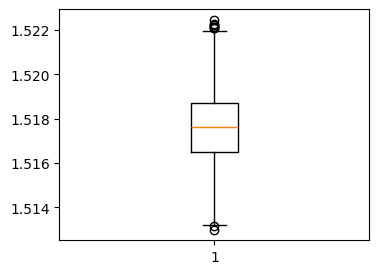

In [ ]:
plt.figure(figsize=(4,3))
plt.boxplot(data.RI)
plt.show()

In [ ]:
data = data[(data['RI'] > 1.514) & (data['RI'] < 1.520)]
data = data[(data['Na'] > 12) & (data['Na'] < 14.3)]
data = data[(data['Al'] > 0.6) & (data['Al'] < 2.1)]
data = data[(data['Si'] > 71.4) & (data['Si'] < 74.2)]
data = data[data['K'] < 1.1]
data = data[(data['Ca'] > 7) & (data['Ca'] < 9.6)]
data = data[data['Ba'] < 0.05]
data = data[data['Fe'] < 0.23]

In [ ]:
data.shape

(106, 10)

In [ ]:
data.Type.value_counts()

,count
Type,
2,47
1,44
3,13
6,2


In [ ]:
""" Посчитайте процент удаленных записей от общего числа записей для каждого класса

1 класс	70-44 = 26/70*100 - 37% удалено
2 класс	76-47 = 29/76*100 - 38% удалено из 2 класса
3	класс 17-13 = 4/17*100 - 23,5% удалено
5	класс 13 - 100% удалено
6	класс 9-2 = 7/9*100 - 78% удалено
7	класс 29 - 100% удалено

214 - 106 = 108/214*100 = 50% данных удалено
"""

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(data.drop(columns='Type'), data['Type'], test_size=0.2, random_state=0)

In [ ]:
forest_n = RandomForestClassifier(class_weight='balanced', random_state=0).fit(x_train, y_train)
pred_n = forest_n.predict(x_test)
result_n = accuracy_score(y_test, pred_n)
result_n

# Несмотря на потерю 50% данных при удалении выбросов, метрика улучшилась с 0.65 до 0.86

0.8636363636363636

In [ ]:
"""
Результат во 2 варианте 0.86, в 1 варианте 0.66 - из-за того, что при обучении модели не был учтён дисбаланс классов.
У Random Forest есть такой параметр.
Также метрика до удаления выбросов во 2 варианте выше: 0.72 и 0.62.
Причина худшей метрики - нормализация. В этих данных она не помогла, а наоборот ухудшила результат.
в 1 варианте было удалено 37% выбросов, во 2 варианте - 50%.
"""

### 1 вариант

In [ ]:
data = pd.read_csv('glass.csv')
one = data['Type'].value_counts()
# у нас 6 классов, отсутствует цифра/класс 4. Большее количество данных рапределены в 1 и 2 классах
one

,count
Type,
2,76
1,70
7,29
3,17
5,13
6,9


In [ ]:
data['Type'].value_counts(normalize=True)

,proportion
Type,
2,0.355140
1,0.327103
7,0.135514
3,0.079439
5,0.060748
6,0.042056


In [ ]:
size = len(data)
size

214

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [ ]:
data.sample(5)

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
166,1.52151,11.03,1.71,1.56,73.44,0.58,11.62,0.0,0.0,5
93,1.51590,13.24,3.34,1.47,73.10,0.39,8.22,0.0,0.0,2
44,1.51786,12.73,3.43,1.19,72.95,0.62,8.76,0.0,0.3,1
77,1.51627,13.00,3.58,1.54,72.83,0.61,8.04,0.0,0.0,2
38,1.52213,14.21,3.82,0.47,71.77,0.11,9.57,0.0,0.0,1


In [ ]:
data.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


In [ ]:
x = data.loc[:, data.columns != 'Type']
y = data['Type']
y

,Type
0,1
1,1
2,1
3,1
4,1
...,...
209,7
210,7
211,7
212,7


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state=7)

In [ ]:
random_for =  RandomForestClassifier(random_state=7).fit(x_train, y_train)

In [ ]:
pred1 = random_for.predict_proba(x_test)
pred1[:5]

array([[0.22, 0.73, 0.  , 0.05, 0.  , 0.  ],
       [0.93, 0.02, 0.05, 0.  , 0.  , 0.  ],
       [0.48, 0.19, 0.26, 0.02, 0.02, 0.03],
       [0.89, 0.06, 0.05, 0.  , 0.  , 0.  ],
       [0.48, 0.  , 0.41, 0.  , 0.1 , 0.01]])

In [ ]:
pred2 = random_for.predict(x_test)
pred2

array([2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 2, 2, 1, 1, 2, 2, 6, 2, 5,
       2, 7, 2, 6, 7, 1, 1, 2, 7, 1, 1, 5, 1, 7, 2, 1, 2, 1, 2, 7, 7])

In [ ]:
print(f'Результат по обучающей выборке: {random_for.score(x_train, y_train)}')
print(f'Результат по тестовой выборке: {random_for.score(x_test, y_test): .3f}')
# возможно, что здесь переобучение, а может и нет, сложно мне соориентироваться, так как первый раз пробую с многоклассовой выборкой

Результат по обучающей выборке: 1.0
Результат по тестовой выборке:  0.628


In [ ]:
accuracy_score(y_test, pred2) # результат неплохой, но, наверное, здесь дисбаланс классов,
# 1 и 2 класс содержат в себе основное количество данных и accuracy не подходит

0.627906976744186

In [ ]:
x.columns

Index(['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe'], dtype='object')

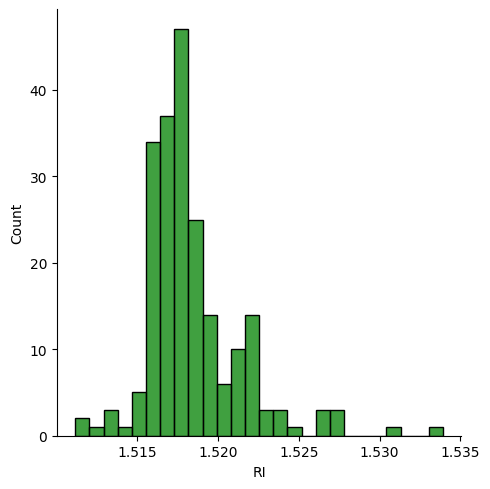

In [ ]:
sns.displot(data['RI'], color='green') # что-то вроде нормального распределения

<Axes: ylabel='RI'>

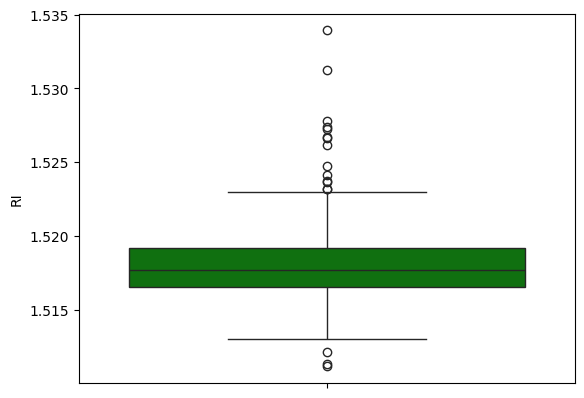

In [ ]:
sns.boxplot(data['RI'], color='green')

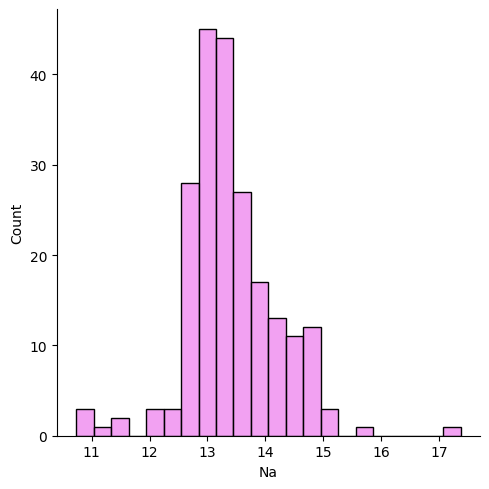

In [ ]:
sns.displot(data['Na'], color='violet') # более-менее похоже на нормальное распределение

<Axes: ylabel='Na'>

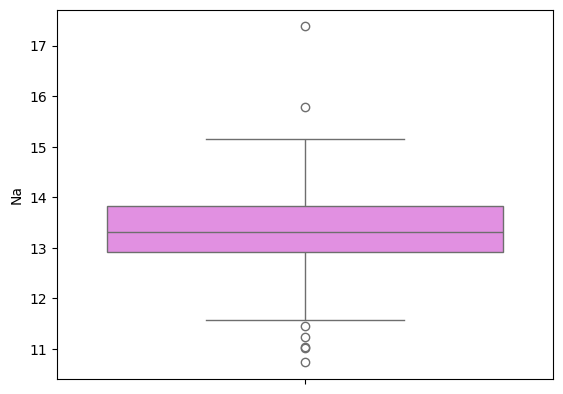

In [ ]:
sns.boxplot(data['Na'], color='violet')

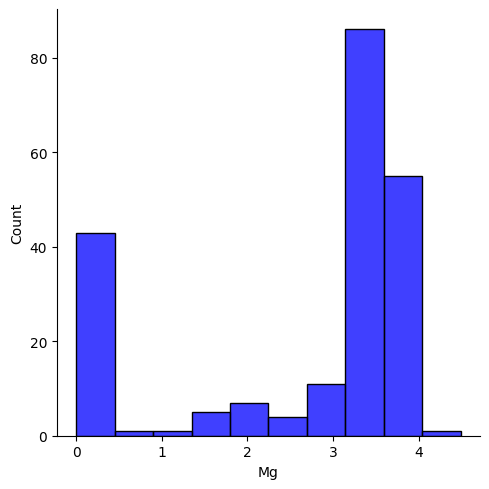

In [ ]:
sns.displot(data['Mg'], color='blue')

<Axes: ylabel='Mg'>

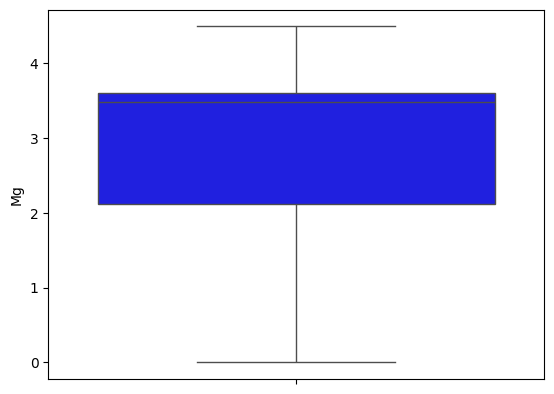

In [ ]:
sns.boxplot(data['Mg'], color='blue') # нет выбросов

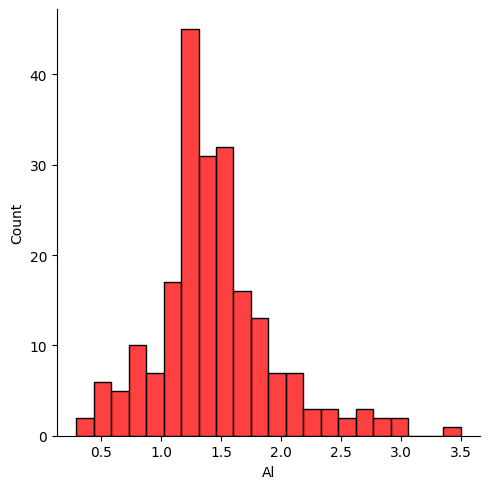

In [ ]:
sns.displot(data['Al'], color='red') # мне кажется здесь что-то вроде нормального распределения

<Axes: ylabel='Al'>

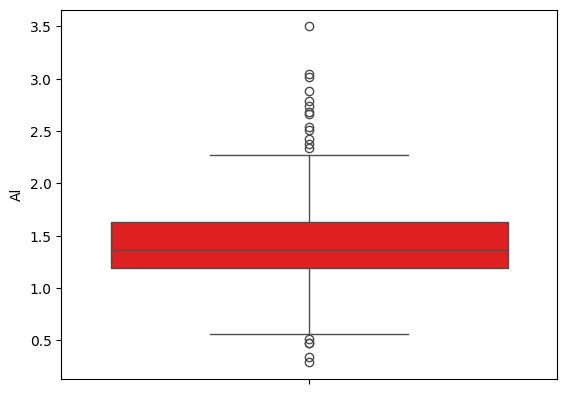

In [ ]:
sns.boxplot(data['Al'], color='red')

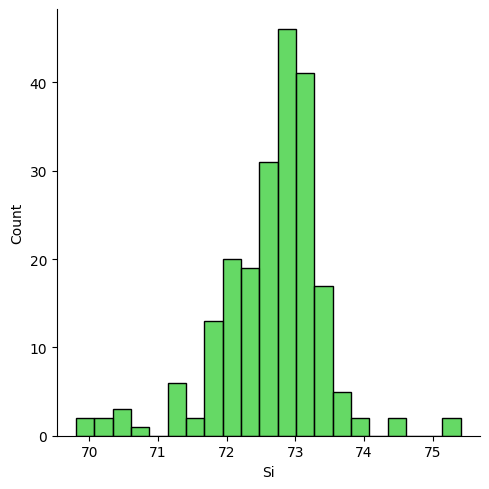

In [ ]:
sns.displot(data['Si'], color='limegreen') # здесь не очень далеко от нормального распределения

<Axes: ylabel='Si'>

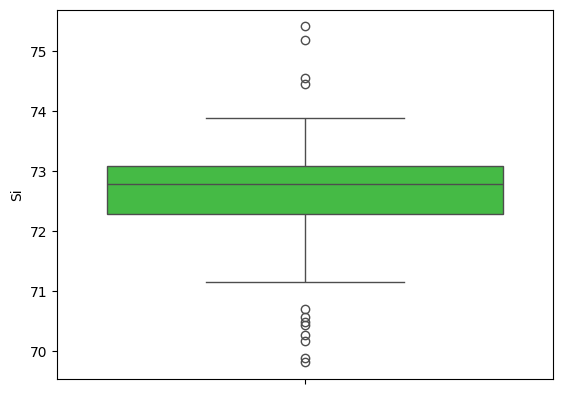

In [ ]:
sns.boxplot(data['Si'], color='limegreen')

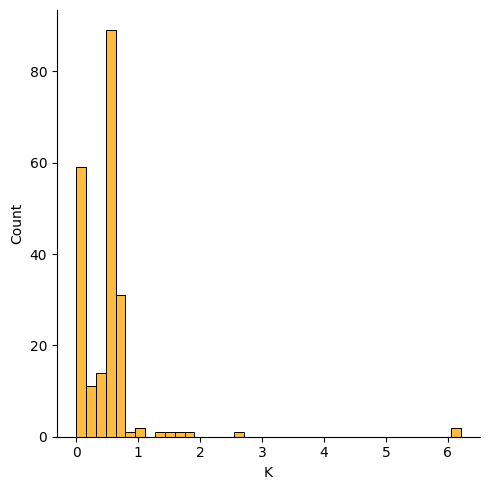

In [ ]:
sns.displot(data['K'], color='orange')

<Axes: ylabel='K'>

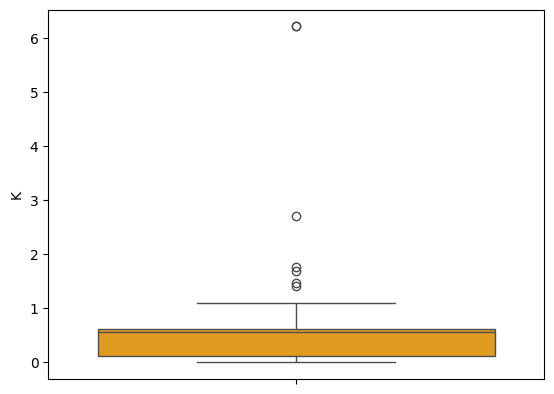

In [ ]:
sns.boxplot(data['K'], color='orange')

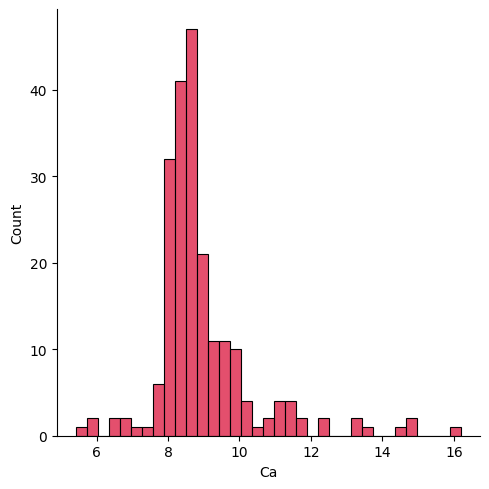

In [ ]:
sns.displot(data['Ca'], color='crimson') # в принципе что-то похожее на нормальное распределение

<Axes: ylabel='Ca'>

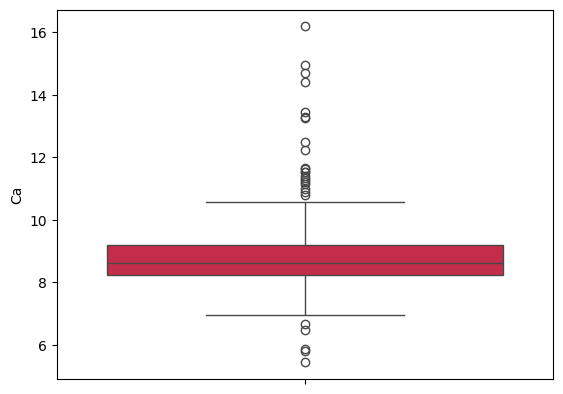

In [ ]:
sns.boxplot(data['Ca'], color='crimson')

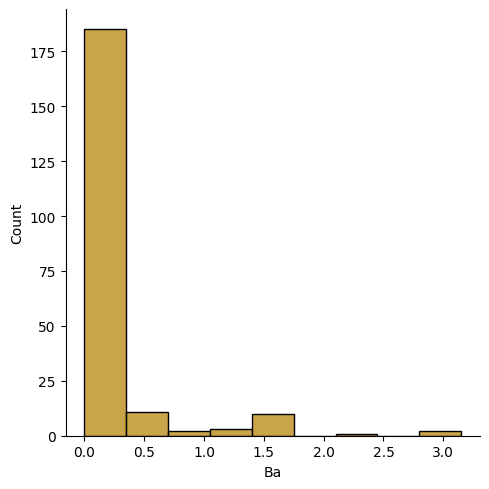

In [ ]:
sns.displot(data['Ba'], color='darkgoldenrod')

<Axes: ylabel='Ba'>

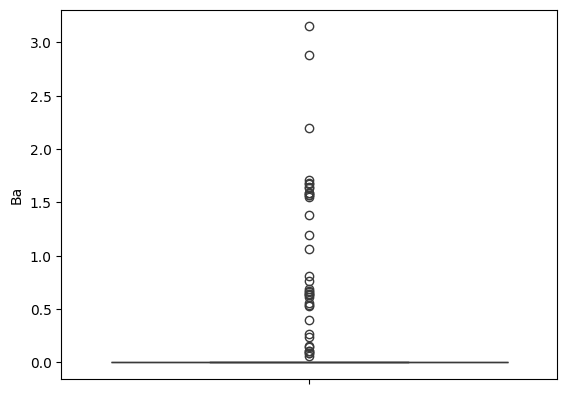

In [ ]:
sns.boxplot(data['Ba'], color='darkgoldenrod')
# это что-то очень странное, и как искать здесь выбросы?
# как будто начиная с 0, пошли выбросы......

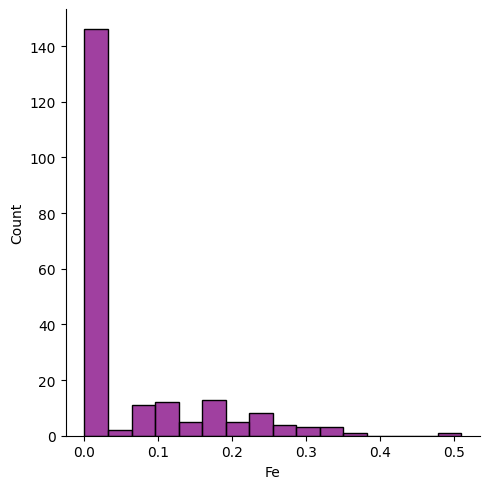

In [ ]:
sns.displot(data['Fe'], color='purple')

<Axes: ylabel='Fe'>

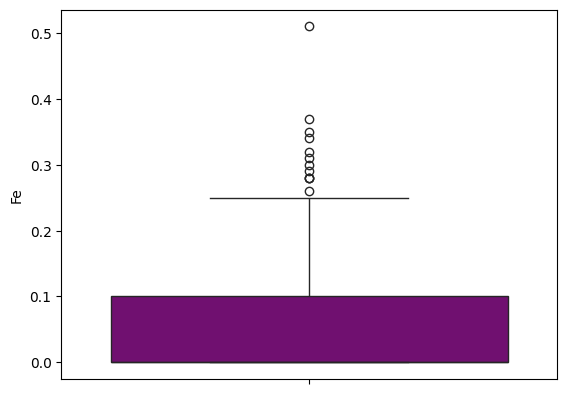

In [ ]:
sns.boxplot(data['Fe'], color='purple')

In [ ]:
iso_for = IsolationForest().fit(x)
iso_for_pred = iso_for.predict(x)
iso_for_pred
# -1 выбросы. Вообще очень наглядно на boxplot видны выбросы, но 1000 признаков не просмотришь)) В этом датасете много выбросов, конечно

array([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1, -1,  1, -1, -1, -1,  1,  1, -1, -1, -1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1, -1, -1,  1,  1,  1,  1,  1,  1,
        1, -1, -1,  1, -1, -1,  1,  1,  1,  1,  1,  1,  1,  1, -1, -1, -1,
        1, -1, -1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,
        1,  1,  1, -1,  1,  1,  1,  1,  1,  1])

In [ ]:
x = MinMaxScaler().fit_transform(x)

In [ ]:
db = DBSCAN(eps=0.5, min_samples=10)
db.fit(x)

DBSCAN(min_samples=10)

In [ ]:
mask = np.zeros_like(db.labels_, dtype=bool)
mask[db.core_sample_indices_] = True
mask
# мне кажется похожи выбросы на предыдущий показатель Изолирующиего леса

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True, False, False, False,
        True, False, False, False, False,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

In [ ]:
data = data[(data['RI'] > 1.510) & (data['RI'] < 1.523)]
data = data[(data['Na'] > 11.5) & (data['Na'] < 15.1)]
data = data[(data['Al'] > 0.6) & (data['Al'] < 2.3)]
data = data[(data['Si'] > 71) & (data['Al'] < 74)]
data = data[(data['K'] < 1.1)]
data = data[(data['Ca'] > 7) & (data['Ca'] < 10.5)]
data = data[(data['Ba'] < 0.04)]
data = data[(data['Fe'] < 0.25)]

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 133 entries, 0 to 181
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      133 non-null    float64
 1   Na      133 non-null    float64
 2   Mg      133 non-null    float64
 3   Al      133 non-null    float64
 4   Si      133 non-null    float64
 5   K       133 non-null    float64
 6   Ca      133 non-null    float64
 7   Ba      133 non-null    float64
 8   Fe      133 non-null    float64
 9   Type    133 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 11.4 KB


In [ ]:
print(f'Процент удалённых выбросов:  {((214 - 133) /214 *100):.2f} %')

Процент удалённых выбросов:  37.85 %


In [ ]:
two = data['Type'].value_counts()
two

,count
Type,
1,58
2,53
3,14
6,6
5,2


In [ ]:
data['Type'].value_counts(normalize=True)
# после выбросов соотношение в % от общего числа, уменьшилось до 133

,proportion
Type,
1,0.436090
2,0.398496
3,0.105263
6,0.045113
5,0.015038


In [ ]:
three = (one - two) / size *100
print(f'Процент удалённых записей от общего числа записей для каждого класса: \n{three}')

Процент удалённых записей от общего числа записей для каждого класса: 
Type
1     5.607477
2    10.747664
3     1.401869
5     5.140187
6     1.401869
7          NaN
Name: count, dtype: float64


In [ ]:
x = data.loc[:, data.columns != 'Type']
y = data['Type']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state=7)

In [ ]:
ran_for =  RandomForestClassifier(random_state=7).fit(x_train, y_train)

In [ ]:
pr = ran_for.predict(x_test)

In [ ]:
accuracy_score(y_test, pr)
# до удаления выбросов результат был 0.627906976744186
# конечно, результат лучше, но удалено 37% данных, наверное, это много очень и стоит заменять выбросы

0.6666666666666666